In [1]:
import ccxt
import pandas as pd
# 更簡潔的引入方式 - 直接從套件引入類別
from src import Create_funding_fetcher,Create_klines_fetcher,FundingFetcher,KlinesFetcher
# 使用套件定義的常數
from pipeline import DataMerge, DataTransform
from backtest import Backtester
from tqdm import tqdm

In [41]:
def calculate_margin(position, leverage):
    spot = position * (1 - (1 / (leverage + 1)))
    margin = position - spot
    print(f"Position: {position}, Leverage: {leverage}, Margin: {margin}, Spot: {spot},spot + margin: {spot + margin}")
    return spot, margin



### Binance symbol has perps no spot

In [2]:
# pip install ccxt
import ccxt

def perps_without_spot(exchange_id: str):
    ex = getattr(ccxt, exchange_id)({
        "enableRateLimit": True,
        # optional: "timeout": 20000,
    })
    ex.load_markets()
    markets = ex.markets  # dict(symbol -> market dict)

    # Build quick lookups
    spot_symbols = set(sym for sym, m in markets.items() if m.get('spot'))
    perp_markets = [m for m in markets.values() if m.get('swap') and (m.get('contract') or m.get('linear') or m.get('inverse'))]

    # For each perp, construct a "spot-like" symbol key to check against spot availability
    results = []
    for m in perp_markets:
        # Most perps look like "BTC/USDT:USDT" or "BTC/USDT" but m['symbol'] always exists,
        # and m['base'], m['quote'] give canonical assets.
        base = m.get('base')
        quote = m.get('quote')
        if not base or not quote:
            continue
        spot_key = f"{base}/{quote}"
        if spot_key not in spot_symbols:
            results.append({
                "perp_symbol": m['symbol'],
                "missing_spot_pair": spot_key,
            })
    df = pd.DataFrame(results)
    binance_perps = df.perp_symbol.sort_values().tolist()
    binance_perps = [symbol.split("/")[0] for symbol in binance_perps if 'USDT' in symbol]
    return binance_perps


In [3]:
binance_perps_without_spot = perps_without_spot("binance")

### Backtest for Binance 

In [44]:
# for symbol in tqdm(bin_hyper):
#     symbol_ = symbol + "/USDT:USDT"
#     FundingFetcher.binance.get_data(symbol_)
#     # KlinesFetcher.hyperliquid.get_data(symbol_ + '/USDC:USDC', '1h', since=None, limit=1000)
#     KlinesFetcher.binance.get_data(symbol_)

In [ ]:
loader = DataTransform(exchange_id='binance')
loader.transform_all_symbols()

In [5]:
backtest_binance = Backtester(exchange1='binance')

Backtester: Single-exchange mode: binance | Symbols: 583


In [13]:
profolio_df,stat,all_symbol_df,failed_symbols= backtest_binance.backtest_portfolio(symbols=binance_perps_without_spot,max_active_positions=1000,n_days=3, threshold=0.1,
                         out_threshold=0.05, value_threshold=5000000, value_out_threshold=5000000, leverage=1,start_date= '2024-01-01')

Processing symbols:  29%|██▊       | 48/168 [00:00<00:01, 83.81it/s]

[BEAT] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/binance/funding_rates/BEATUSDT.parquet'
[CLANKER] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/binance/funding_rates/CLANKERUSDT.parquet'


Processing symbols:  53%|█████▎    | 89/168 [00:01<00:01, 73.44it/s]

[JCT] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/binance/funding_rates/JCTUSDT.parquet'


Processing symbols: 100%|██████████| 168/168 [00:01<00:00, 107.24it/s]



Merging 165 symbols...
✓ Merge completed | Success: 165/168 | Failed: 3
  Failed: BEAT, CLANKER, JCT


Building portfolio: 100%|██████████| 16284/16284 [00:00<00:00, 25660.33it/s]


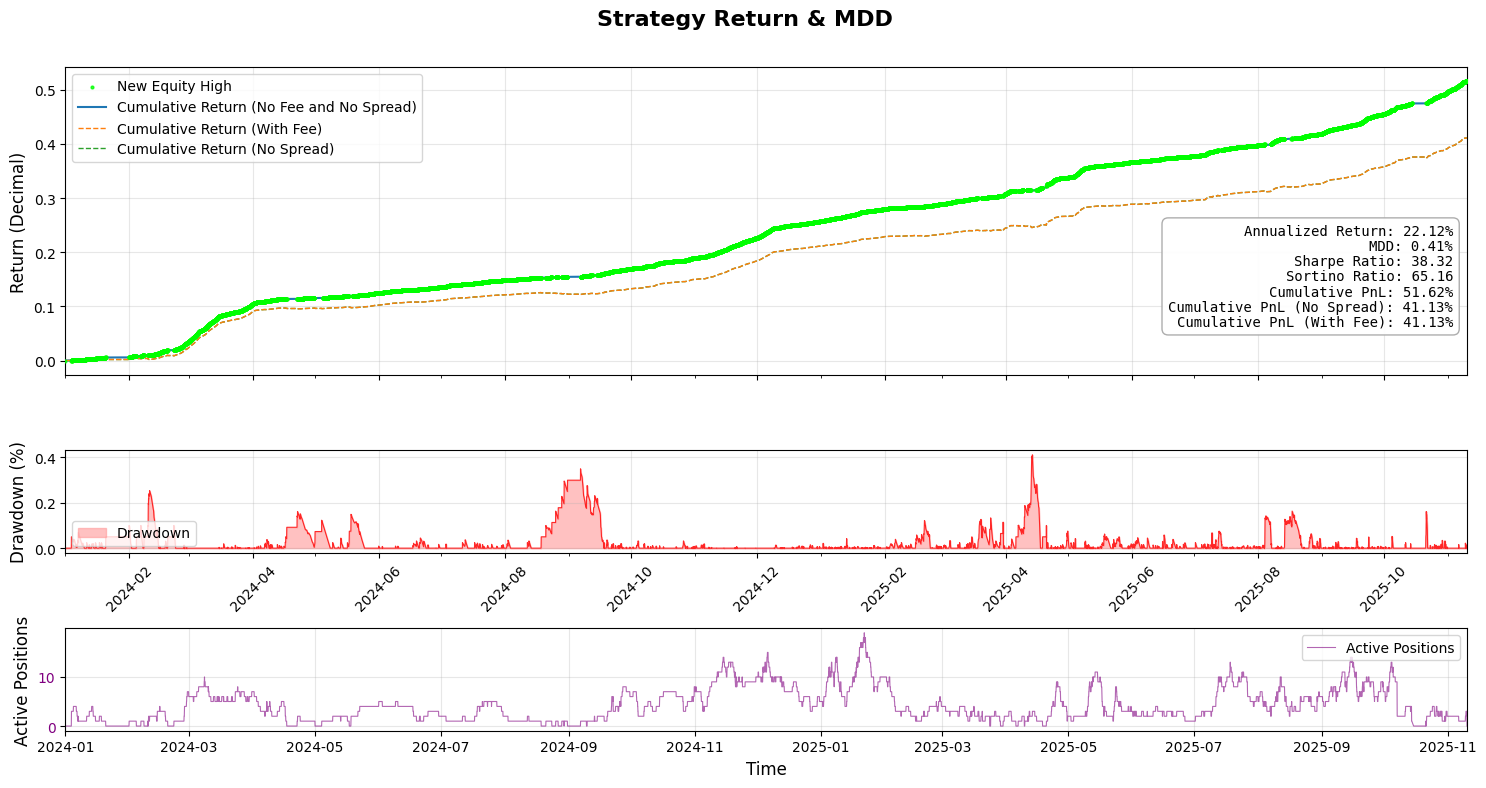

Plot: 16,284 points | 679 days | 2024-01-01 to 2025-11-10


In [14]:
backtest_binance.plot_strategy_performance(profolio_df)

/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/backtest/backtest.py:1060: UserWarning: Glyph 24065 (\N{CJK UNIFIED IDEOGRAPH-5E01}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/backtest/backtest.py:1060: UserWarning: Glyph 23433 (\N{CJK UNIFIED IDEOGRAPH-5B89}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/backtest/backtest.py:1060: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/backtest/backtest.py:1060: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/zhuoweiyi/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24065 (\N{CJK UNIFIED IDEOGRAPH-5E01}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io

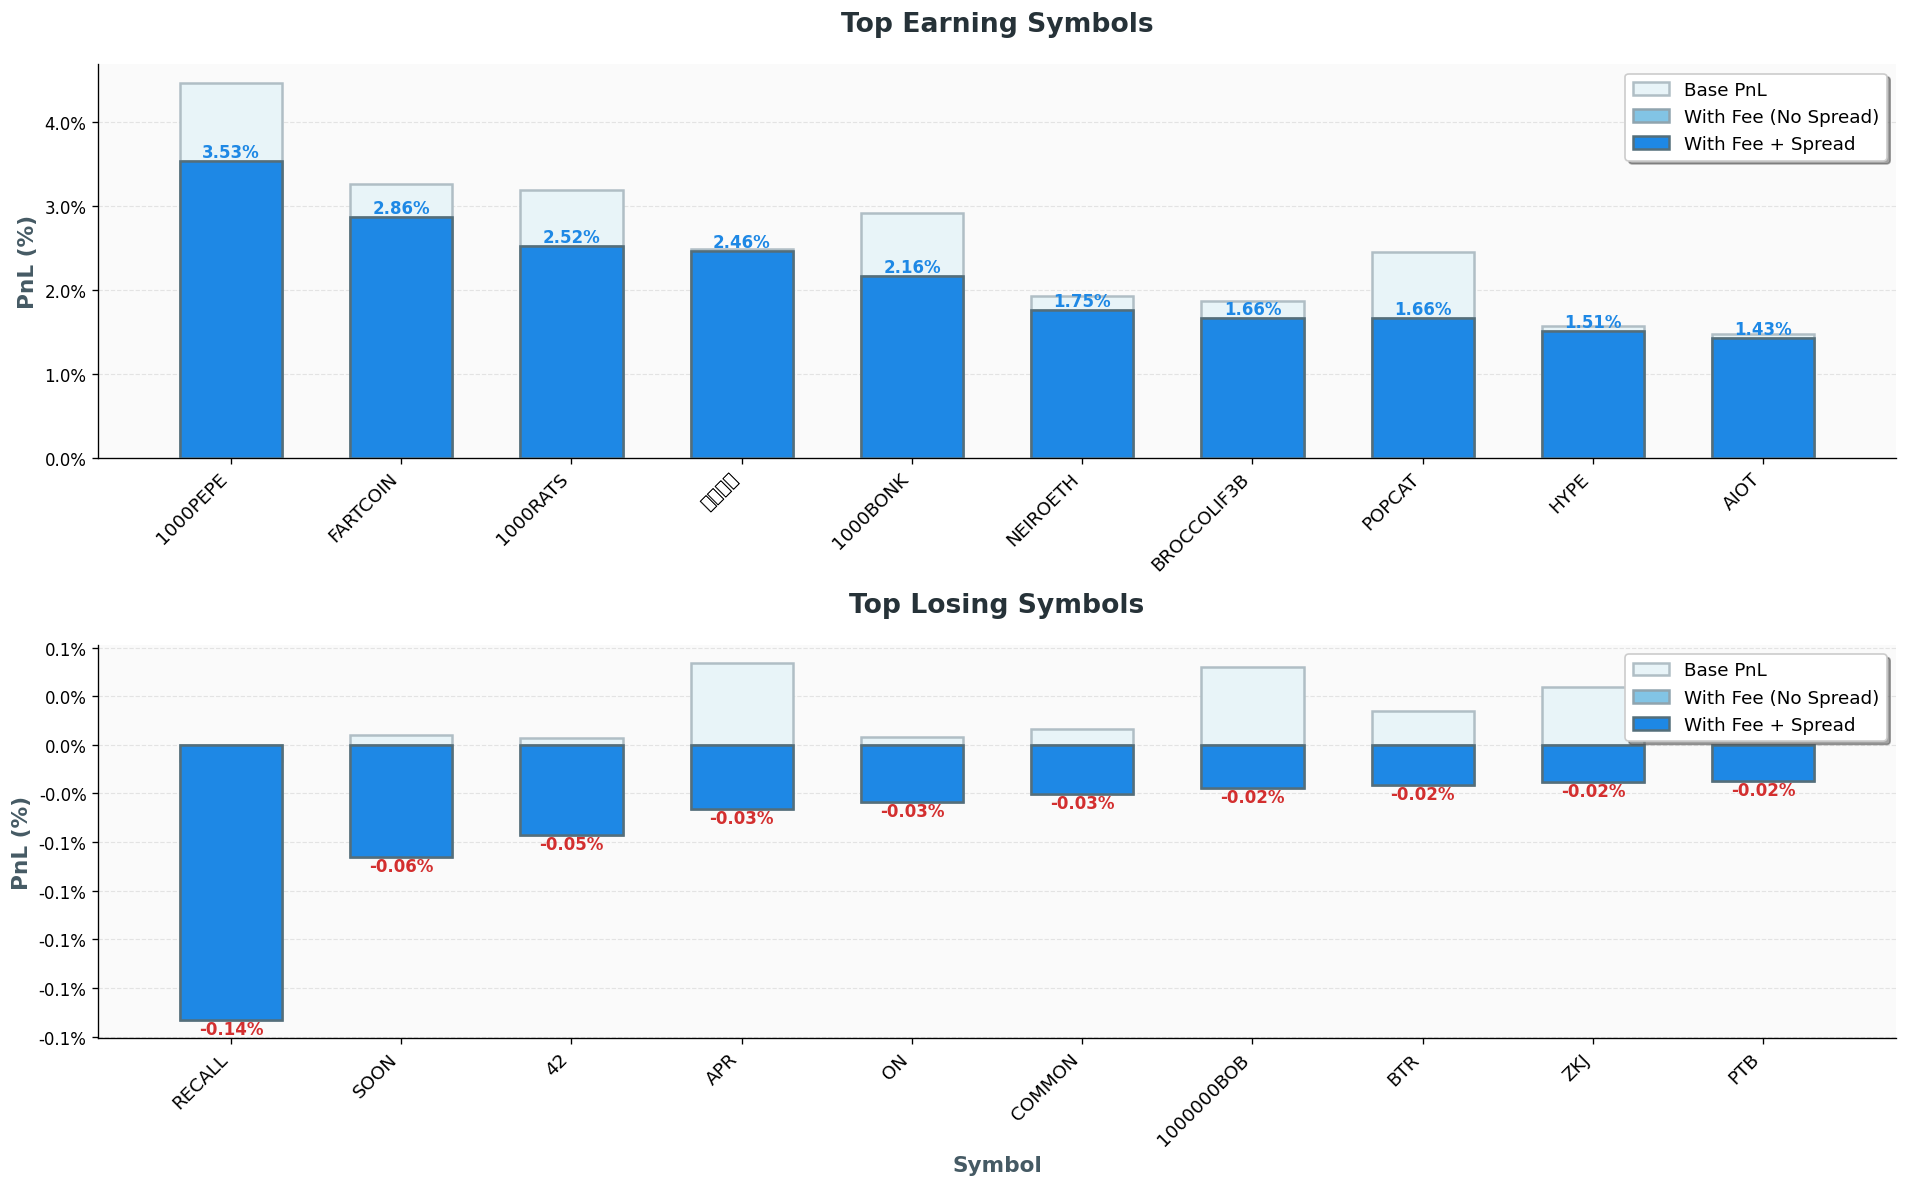


📈 Top 10 Earning: 1000PEPE, FARTCOIN, 1000RATS, 币安人生, 1000BONK, NEIROETH, BROCCOLIF3B, POPCAT, HYPE, AIOT
📉 Top 10 Losing: RECALL, SOON, 42, APR, ON, COMMON, 1000000BOB, BTR, ZKJ, PTB


In [15]:
backtest_binance.plot_top_earning_losing(all_symbol_df,top=10)

### bybit

In [18]:
bybit_perps_without_spot = perps_without_spot(exchange_id='bybit')

In [51]:
# for symbol in tqdm(failed_symbols):
#     symbol_ = symbol + "/USDT:USDT"
#     FundingFetcher.bybit.get_data(symbol_)
#     # KlinesFetcher.hyperliquid.get_data(symbol_ + '/USDC:USDC', '1h', since=None, limit=1000)
#     KlinesFetcher.bybit.get_data(symbol_)
#     loader = DataTransform(exchange_id='bybit')
#     loader.transform_symbol(symbol_)

In [52]:
# loader = DataTransform(exchange_id='bybit')
# loader.transform_all_symbols()

In [16]:
backtest_bybit = Backtester(exchange1='bybit')

Backtester: Single-exchange mode: bybit | Symbols: 598


In [23]:
profolio_df,stat,all_symbol_df,failed_symbols= backtest_bybit.backtest_portfolio(symbols=bybit_perps_without_spot,max_active_positions=1000,n_days=3, threshold=0.1,
                         out_threshold=0.05, value_threshold=5000000, value_out_threshold=5000000, leverage=1,start_date= '2024-01-01')

Processing symbols:  30%|███       | 75/249 [00:01<00:01, 87.47it/s]

[BLUAI] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bybit/funding_rates/BLUAIUSDT.parquet'
[CLO] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bybit/funding_rates/CLOUSDT.parquet'


Processing symbols:  44%|████▍     | 110/249 [00:01<00:01, 99.89it/s]

[EVAA] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bybit/funding_rates/EVAAUSDT.parquet'
[HANA] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bybit/funding_rates/HANAUSDT.parquet'


Processing symbols:  53%|█████▎    | 131/249 [00:01<00:01, 95.33it/s]

[KITE] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bybit/funding_rates/KITEUSDT.parquet'
[LAB] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bybit/funding_rates/LABUSDT.parquet'
[MEGA] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bybit/funding_rates/MEGAUSDT.parquet'


Processing symbols: 100%|██████████| 249/249 [00:02<00:00, 122.85it/s]


[PIGGY] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bybit/funding_rates/PIGGYUSDT.parquet'
[RIVER] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bybit/funding_rates/RIVERUSDT.parquet'
[STABLE] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bybit/funding_rates/STABLEUSDT.parquet'
[TURTLE] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bybit/funding_rates/TURTLEUSDT.parquet'

Merging 238 symbols...
✓ Merge completed | Success: 238/249 | Failed: 11
  Failed: BLUAI, CLO, EVAA, HANA, KITE ... (+6 more)


Building portfolio: 100%|██████████| 16300/16300 [00:00<00:00, 34541.23it/s]


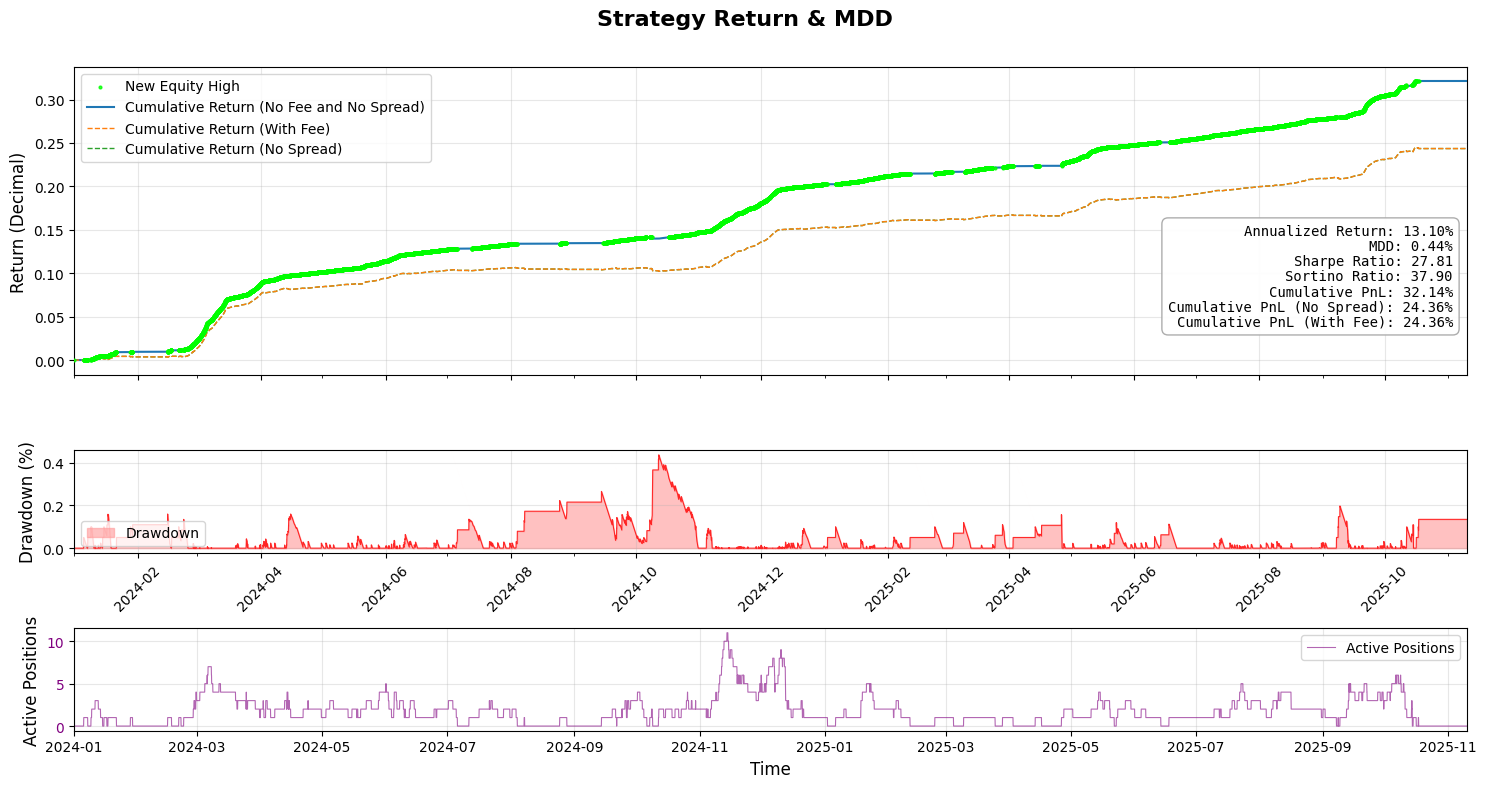

Plot: 16,300 points | 679 days | 2024-01-01 to 2025-11-10


In [24]:
backtest_bybit.plot_strategy_performance(profolio_df)

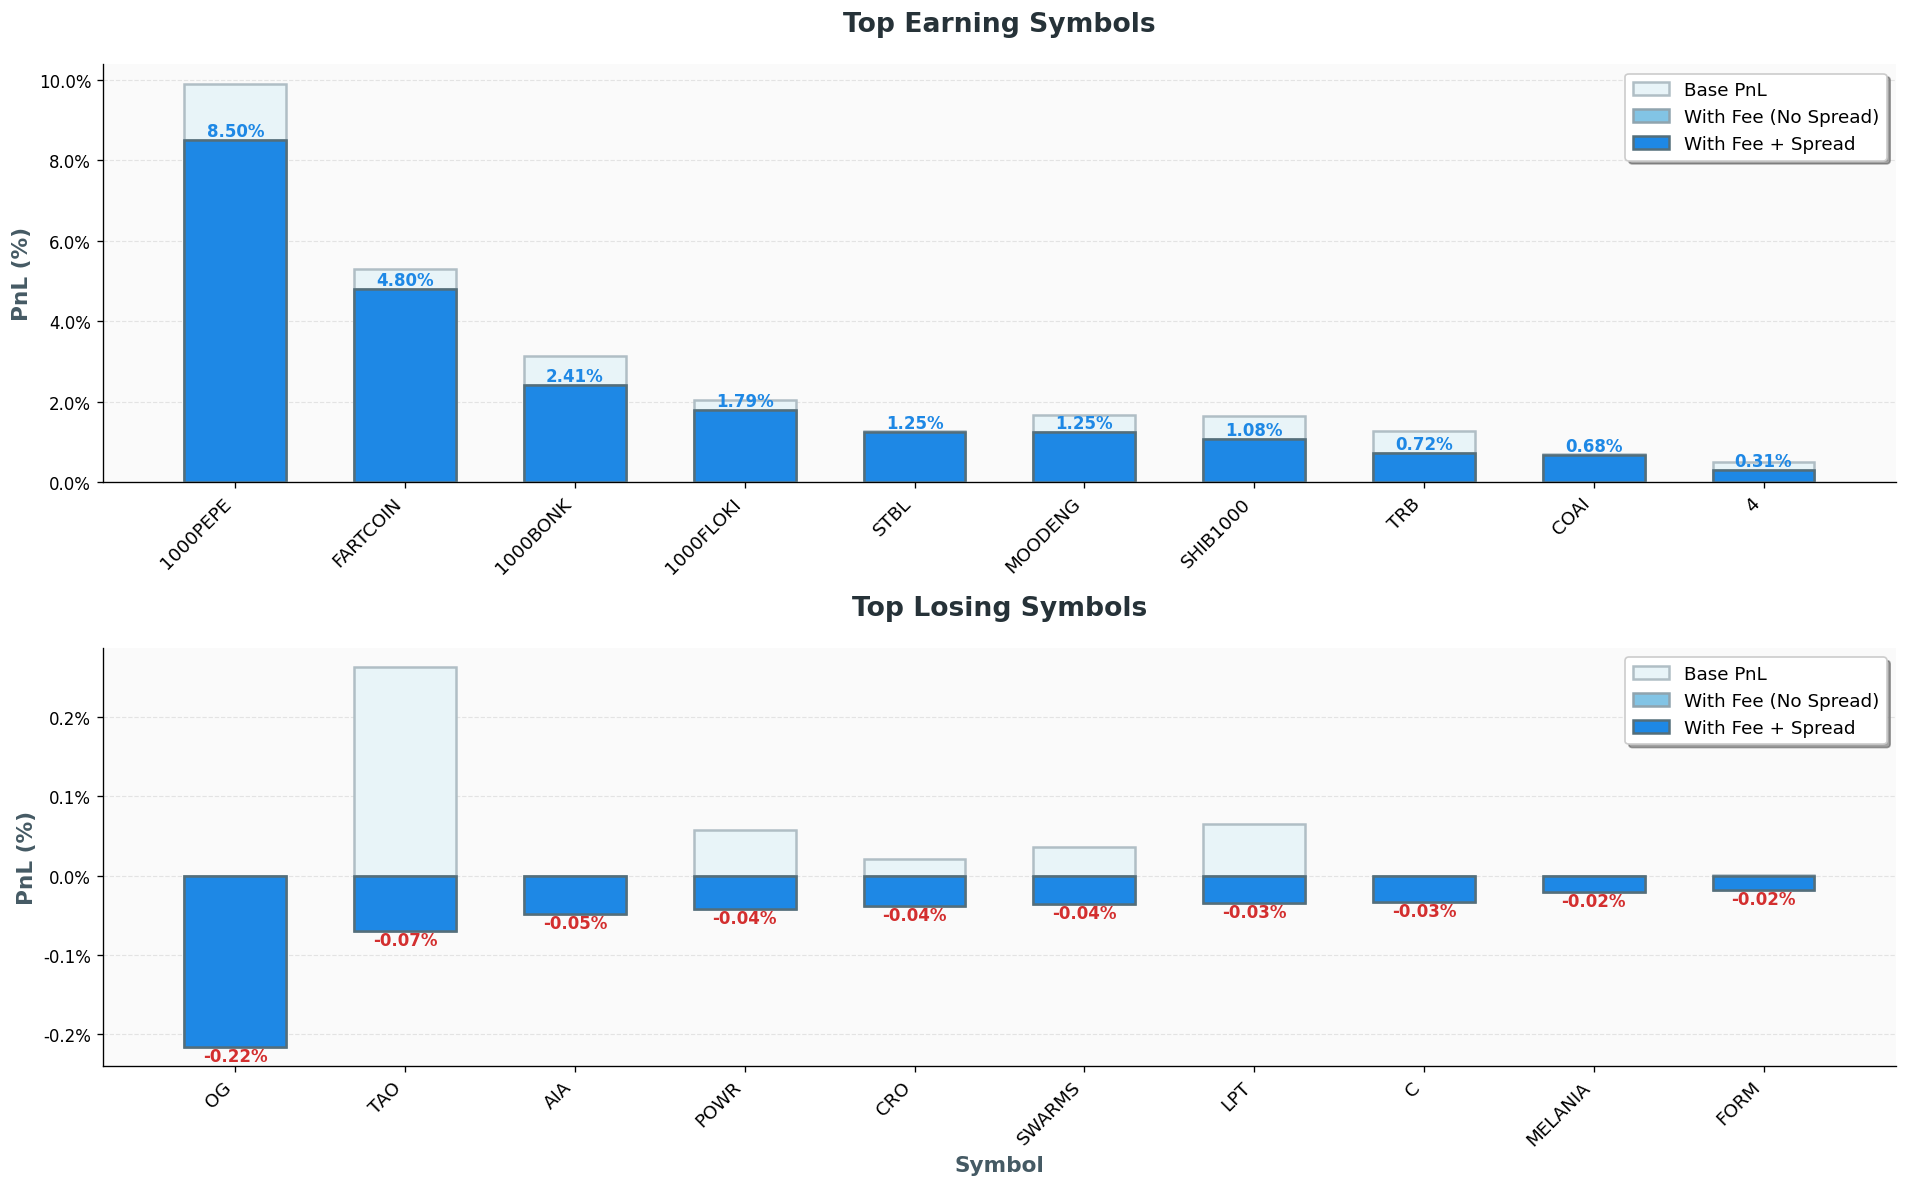


📈 Top 10 Earning: 1000PEPE, FARTCOIN, 1000BONK, 1000FLOKI, STBL, MOODENG, SHIB1000, TRB, COAI, 4
📉 Top 10 Losing: OG, TAO, AIA, POWR, CRO, SWARMS, LPT, C, MELANIA, FORM


In [25]:
backtest_bybit.plot_top_earning_losing(all_symbol_df,top=10)

### bitget

In [26]:
bitget_perps_without_spot = perps_without_spot(exchange_id='bitget')

In [27]:
len(bitget_perps_without_spot)

114

In [59]:
# loader = DataTransform(exchange_id='bitget')
# bitget_k = Create_klines_fetcher(exchange_id='bitget',since = '2025-02-01')

# for symbol in tqdm(bitget_perps_without_spot_filtered):
#     symbol_ = symbol + "/USDT:USDT"
#     try:
#         FundingFetcher.bitget.get_data(symbol_)
#     except Exception as e:
#         print(f"Error fetching funding data for {symbol_}: {e}")
#         continue
#     # KlinesFetcher.hyperliquid.get_data(symbol_ + '/USDC:USDC', '1h', since=None, limit=1000)
#     try:
#         bitget_k.get_data(symbol+ 'USDT')
#         loader.transform_symbol(symbol_)
#     except Exception as e:
#         print(f"Error fetching klines data for {symbol_}: {e}")
#         continue
    


In [28]:
# 過濾掉美股相關的 symbol
us_stocks = {'AAPL', 'AMZN', 'ARM', 'ASML', 'BABA', 'COIN', 'GE', 'GME', 'GOOGL', 
             'HOOD', 'IBM', 'INTC', 'MCD', 'META', 'MRVL', 'MSFT', 'MSTR', 'NVDA', 
             'ORCL', 'PLTR', 'RIOT', 'SLV', 'SPX', 'TSLA'}

bitget_perps_without_spot_filtered = [symbol for symbol in bitget_perps_without_spot if symbol not in us_stocks]


In [29]:
backtest_bitget = Backtester(exchange1='bitget')

Backtester: Single-exchange mode: bitget | Symbols: 584


In [53]:
profolio_df,stat,all_symbol_df,failed_symbols= backtest_bitget.backtest_portfolio(symbols=bitget_perps_without_spot_filtered,max_active_positions=1000,n_days=3, threshold=0.1,
                         out_threshold=0.05, value_threshold=500000, value_out_threshold=500000, leverage=1)

Processing symbols:  26%|██▌       | 23/90 [00:00<00:00, 117.36it/s]

[ACN] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bitget/funding_rates/ACNUSDT.parquet'
[AT] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bitget/funding_rates/ATUSDT.parquet'
[BEAT] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bitget/funding_rates/BEATUSDT.parquet'
[CSCO] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bitget/funding_rates/CSCOUSDT.parquet'
[DASH] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bitget/funding_rates/DASHUSDT.parquet'
[FOLKS] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bitget/funding_rates/FOLKSUSDT.parquet'


Processing symbols: 100%|██████████| 90/90 [00:00<00:00, 217.68it/s]

[FUTU] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bitget/funding_rates/FUTUUSDT.parquet'
[JD] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bitget/funding_rates/JDUSDT.parquet'
[LLY] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bitget/funding_rates/LLYUSDT.parquet'
[MA] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bitget/funding_rates/MAUSDT.parquet'
[PEP] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bitget/funding_rates/PEPUSDT.parquet'
[QQQ] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/bitget/funding_rates/QQQUSDT.parquet'
[RDDT] ❌ Error: [Errno 2] No such file or directory: '/Users

✓ Merge completed | Success: 73/90 | Failed: 17
  Failed: ACN, AT, BEAT, CSCO, DASH ... (+12 more)


Building portfolio: 100%|██████████| 35897/35897 [00:00<00:00, 70999.69it/s]


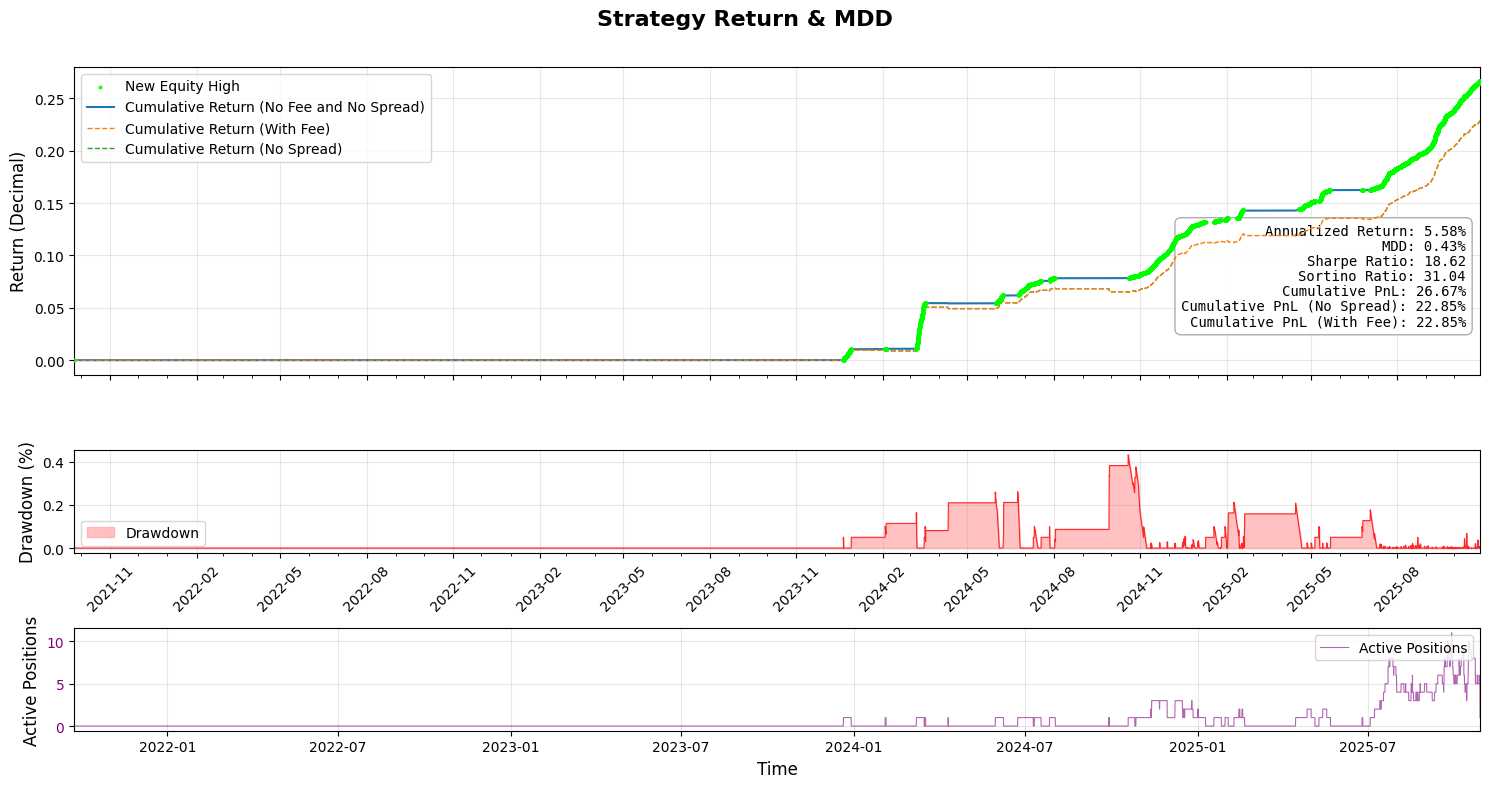

Plot: 35,897 points | 1495 days | 2021-09-23 to 2025-10-28


In [54]:
backtest_bitget.plot_strategy_performance(profolio_df)

In [64]:
stat

{'cumulative_pnl': np.float64(0.021344749999999846),
 'cumulative_pnl_with_fee_no_spread': np.float64(0.018344749999999858),
 'cumulative_pnl_with_fee': np.float64(0.018344749999999858),
 'max_drawdown': 0.0009999999999998899,
 'sharpe_ratio': np.float64(5.085792753190759),
 'sortino_ratio': np.float64(7.387802223548055),
 'trades_entered': np.int64(3),
 'trades_exited': np.int64(3),
 'avg_daily_pnl_with_fee': np.float64(2.129327195401658e-08),
 'annual_rate': np.float64(0.004479888525183829)}

### gateio

In [38]:
gateio_perps_without_spot = perps_without_spot(exchange_id='gateio')

In [33]:
backtest_gateio = Backtester(exchange1='gateio')

Backtester: Single-exchange mode: gateio | Symbols: 590


In [47]:
porfolio_df,stat,all_symbol_df,failed_symbols= backtest_gateio.backtest_portfolio(symbols=gateio_perps_without_spot,max_active_positions=1000,n_days=3, threshold=0.1,
                         out_threshold=0.05, value_threshold=5000000, value_out_threshold=5000000, leverage=1)

Processing symbols: 100%|██████████| 29/29 [00:00<00:00, 359.88it/s]


[JCT] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/gateio/funding_rates/JCTUSDT.parquet'
[APR] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/gateio/funding_rates/APRUSDT.parquet'
[42] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/gateio/funding_rates/42USDT.parquet'
[FOLKS] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/gateio/funding_rates/FOLKSUSDT.parquet'
[DASH] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/gateio/funding_rates/DASHUSDT.parquet'
[FUTUON] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/gateio/funding_rates/FUTUONUSDT.parquet'
[JDON] ❌ Error: [Errno 2] No such file or direct

Building portfolio: 100%|██████████| 34841/34841 [00:00<00:00, 75482.35it/s]
/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/backtest/backtest.py:700: RuntimeWarning: invalid value encountered in scalar divide
  'sharpe_ratio': (df_['base_pnl_with_fee'].mean() * 365 * 24) / (df_['base_pnl_with_fee'].std() * np.sqrt(365 * 24)),
/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/backtest/backtest.py:701: RuntimeWarning: invalid value encountered in scalar divide
  'sortino_ratio': (df_['base_pnl_with_fee'].mean() * 365 * 24) / (np.sqrt(((np.minimum(df_['base_pnl_with_fee'], 0))**2).mean()) * np.sqrt(365 * 24)),


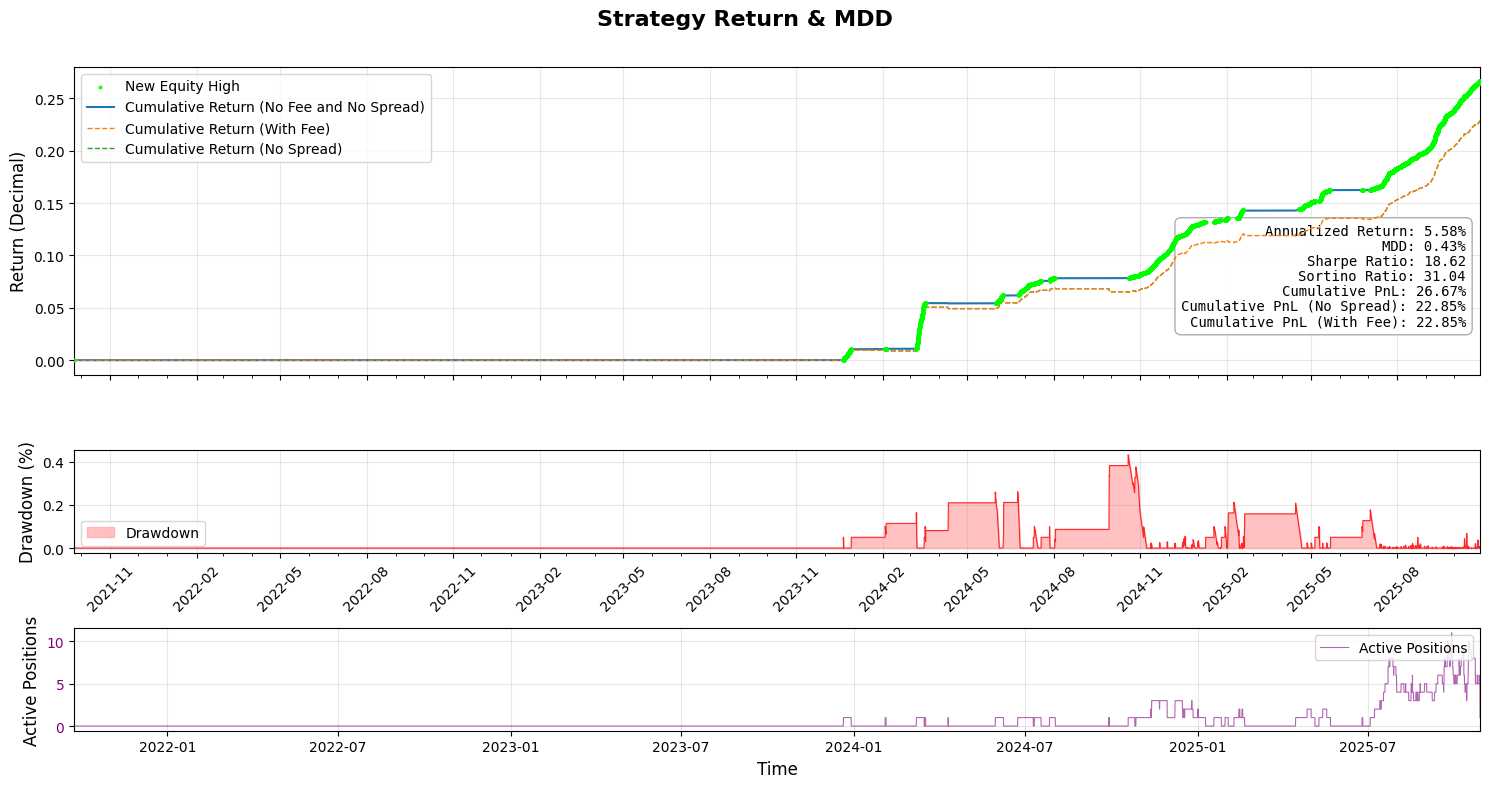

Plot: 35,897 points | 1495 days | 2021-09-23 to 2025-10-28


In [51]:
backtest_gateio.plot_strategy_performance(profolio_df)

### okx

In [41]:
okx_perps_without_spot = perps_without_spot(exchange_id='okx')

In [42]:
backtest_okx = Backtester(exchange1='okx')

Backtester: Single-exchange mode: okx | Symbols: 245


In [46]:
porfolio_df,stat,all_symbol_df,failed_symbols= backtest_okx.backtest_portfolio(symbols=gateio_perps_without_spot,max_active_positions=5,n_days=3, threshold=0.1,
                         out_threshold=0.05, value_threshold=5000000, value_out_threshold=5000000, leverage=1)  

Processing symbols: 100%|██████████| 29/29 [00:00<00:00, 3407.71it/s]


[CLO] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/okx/funding_rates/CLOUSDT.parquet'
[ALL] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/okx/funding_rates/ALLUSDT.parquet'
[42] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/okx/funding_rates/42USDT.parquet'
[JDON] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/okx/funding_rates/JDONUSDT.parquet'
[LYN] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/okx/funding_rates/LYNUSDT.parquet'
[TRUTH] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/data/clean/okx/funding_rates/TRUTHUSDT.parquet'
[币安人生] ❌ Error: [Errno 2] No such file or directory: '/Users/zhuoweiyi/D

Building portfolio: 100%|██████████| 329/329 [00:00<00:00, 71987.38it/s]
/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/backtest/backtest.py:700: RuntimeWarning: invalid value encountered in scalar divide
  'sharpe_ratio': (df_['base_pnl_with_fee'].mean() * 365 * 24) / (df_['base_pnl_with_fee'].std() * np.sqrt(365 * 24)),
/Users/zhuoweiyi/Desktop/Bincentive/Cross_fr_arbitrage/backtest/backtest.py:701: RuntimeWarning: invalid value encountered in scalar divide
  'sortino_ratio': (df_['base_pnl_with_fee'].mean() * 365 * 24) / (np.sqrt(((np.minimum(df_['base_pnl_with_fee'], 0))**2).mean()) * np.sqrt(365 * 24)),
